In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import librosa
import io
import soundfile as sf

from datasets import load_dataset, Audio
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    accuracy_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)

print("EXP-03: Adaptive Threshold VAD")

In [2]:
dataset = load_dataset(
    "guynich/librispeech_asr_test_vad",
    split="test.clean",
    streaming=True
)

dataset = dataset.cast_column(
    "audio",
    Audio(decode=False)
)

sample = next(iter(dataset))

audio_data = sample["audio"]

if audio_data["bytes"] is not None:
    y, sr = sf.read(io.BytesIO(audio_data["bytes"]))
else:
    y, sr = sf.read(audio_data["path"])

if y.ndim > 1:
    y = y.mean(axis=1)

reference = np.asarray(sample["speech"], dtype=int)
confidence = np.asarray(sample["confidence"], dtype=int)

print("Dosya:", sample["file"])
print("Ses süresi:", round(len(y) / sr, 3), "saniye")
print("Örnekleme frekansı:", sr, "Hz")

Dosya: 6930-75918-0000.flac
Ses süresi: 3.505 saniye
Örnekleme frekansı: 16000 Hz


In [3]:
def add_noise(signal, snr_db, seed=42):

    rng = np.random.default_rng(seed)

    noise = rng.normal(0, 1, len(signal))

    signal_power = np.mean(signal ** 2)
    noise_power = np.mean(noise ** 2)

    target_noise_power = signal_power / (
        10 ** (snr_db / 10)
    )

    noise = noise * np.sqrt(
        target_noise_power / noise_power
    )

    return signal + noise


signals = {
    "Clean": y,
    "20 dB": add_noise(y, 20),
    "10 dB": add_noise(y, 10),
    "0 dB": add_noise(y, 0)
}

print("Dört ses koşulu hazır.")

Dört ses koşulu hazır.


In [4]:
frame_ms = 25
hop_ms = 10

frame_length = int(sr * frame_ms / 1000)
hop_length = int(sr * hop_ms / 1000)

rms_results = {}

for name, signal in signals.items():

    rms_results[name] = librosa.feature.rms(
        y=signal,
        frame_length=frame_length,
        hop_length=hop_length,
        center=False
    )[0]

rms_times = (
    np.arange(len(rms_results["Clean"])) * hop_length
    + frame_length / 2
) / sr

print("RMS değerleri hesaplandı.")

RMS değerleri hesaplandı.


In [5]:
def calculate_adaptive_threshold(
    rms_values,
    rms_times,
    noise_duration=0.5,
    alpha=2.0
):

    noise_frames = rms_values[
        rms_times < noise_duration
    ]

    noise_energy = np.mean(noise_frames)

    adaptive_threshold = alpha * noise_energy

    return adaptive_threshold, noise_energy


adaptive_thresholds = {}

for name, rms_values in rms_results.items():

    threshold, noise_energy = calculate_adaptive_threshold(
        rms_values,
        rms_times
    )

    adaptive_thresholds[name] = threshold

    print(
        f"{name:6s} | "
        f"Noise RMS: {noise_energy:.5f} | "
        f"Adaptive Threshold: {threshold:.5f}"
    )

Clean  | Noise RMS: 0.00336 | Adaptive Threshold: 0.00673
20 dB  | Noise RMS: 0.00458 | Adaptive Threshold: 0.00915
10 dB  | Noise RMS: 0.00997 | Adaptive Threshold: 0.01993
0 dB   | Noise RMS: 0.02963 | Adaptive Threshold: 0.05926


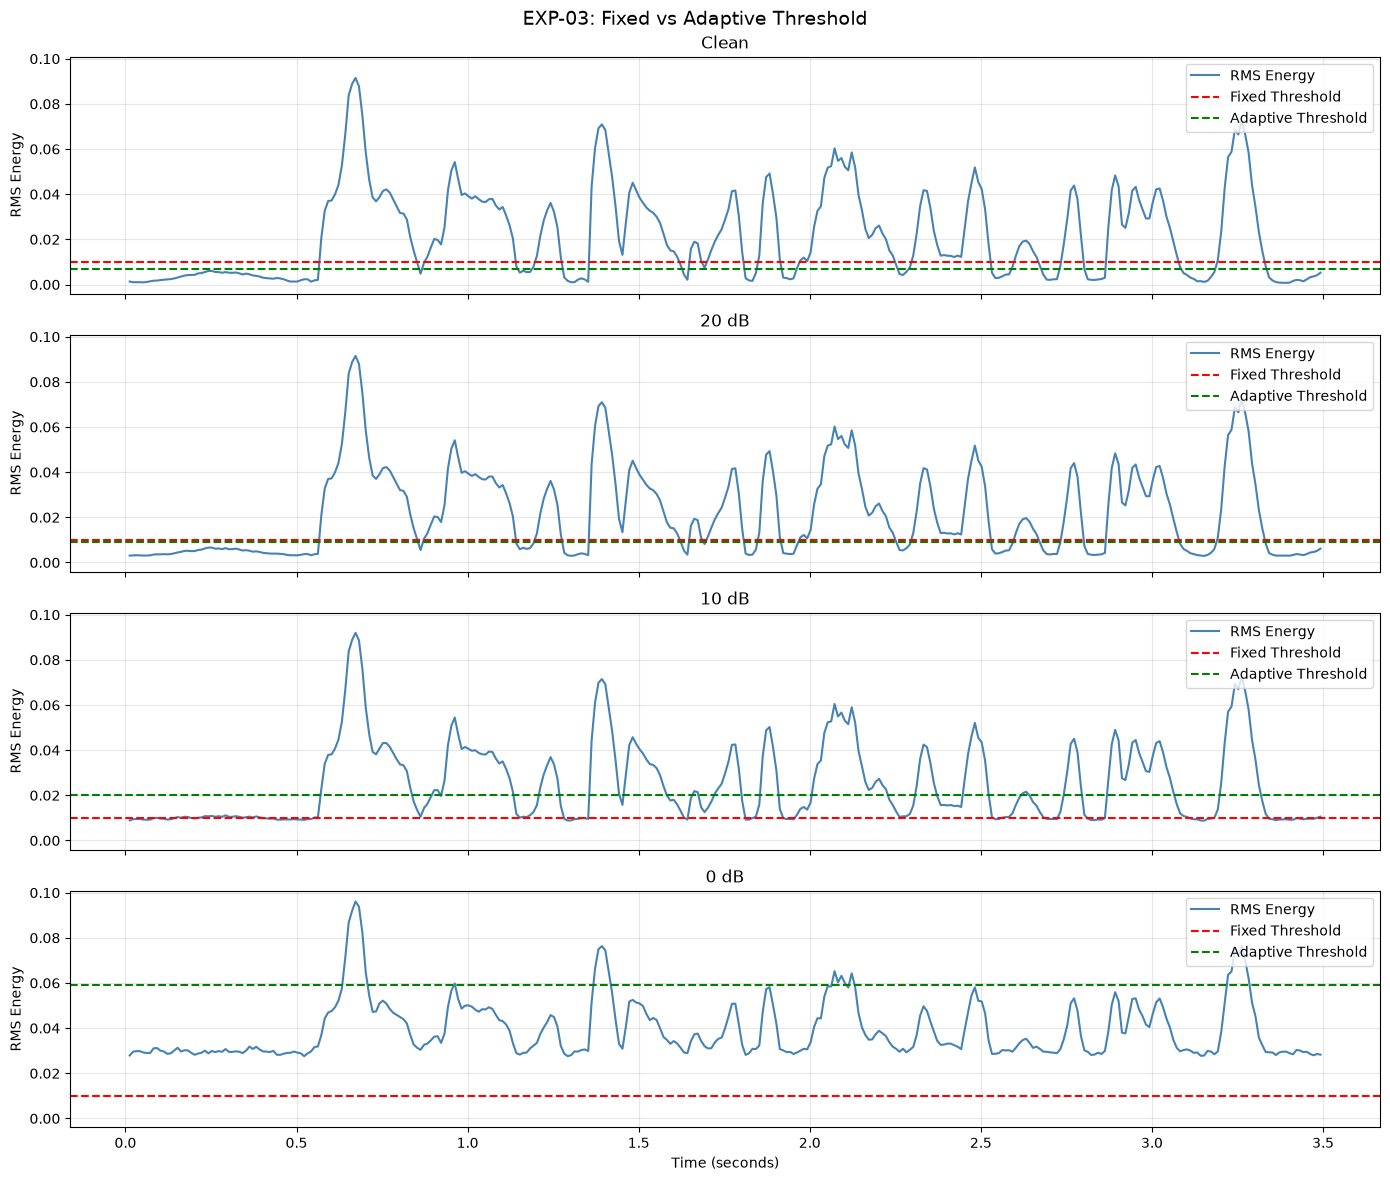

In [6]:
fixed_threshold = 0.01

fig, axes = plt.subplots(
    4, 1,
    figsize=(14, 12),
    sharex=True,
    sharey=True
)

for ax, (name, rms_values) in zip(
    axes,
    rms_results.items()
):

    adaptive_threshold = adaptive_thresholds[name]

    ax.plot(
        rms_times,
        rms_values,
        color="steelblue",
        label="RMS Energy"
    )

    ax.axhline(
        fixed_threshold,
        color="red",
        linestyle="--",
        label="Fixed Threshold"
    )

    ax.axhline(
        adaptive_threshold,
        color="green",
        linestyle="--",
        label="Adaptive Threshold"
    )

    ax.set_title(name)
    ax.set_ylabel("RMS Energy")
    ax.legend(loc="upper right")
    ax.grid(alpha=0.3)

axes[-1].set_xlabel("Time (seconds)")

plt.suptitle(
    "EXP-03: Fixed vs Adaptive Threshold",
    fontsize=14
)

plt.tight_layout()
plt.show()

In [7]:
# Referans etiketleri yaklaşık zaman eksenine yerleştir
duration = len(y) / sr

reference_times = (
    np.arange(len(reference)) + 0.5
) * duration / len(reference)

# Referans zamanlarına en yakın RMS frame'lerini bul
indices = np.abs(
    rms_times[:, None] - reference_times[None, :]
).argmin(axis=0)

# Belirsiz etiketleri değerlendirme dışında bırak
valid = confidence == 1

fixed_threshold = 0.01

comparison_results = {}

for name, rms_values in rms_results.items():

    adaptive_threshold = adaptive_thresholds[name]

    methods = {
        "Fixed": fixed_threshold,
        "Adaptive": adaptive_threshold
    }

    comparison_results[name] = {}

    for method, threshold in methods.items():

        prediction = (rms_values > threshold).astype(int)
        aligned_prediction = prediction[indices]

        y_true = reference[valid]
        y_pred = aligned_prediction[valid]

        tn, fp, fn, tp = confusion_matrix(
            y_true,
            y_pred,
            labels=[0, 1]
        ).ravel()

        result = {
            "Precision": precision_score(
                y_true, y_pred, zero_division=0
            ),
            "Recall": recall_score(
                y_true, y_pred, zero_division=0
            ),
            "F1": f1_score(
                y_true, y_pred, zero_division=0
            ),
            "Accuracy": accuracy_score(y_true, y_pred),
            "TP": tp,
            "TN": tn,
            "FP": fp,
            "FN": fn
        }

        comparison_results[name][method] = result

        print(f"\n{name} - {method}")
        print(f"Threshold: {threshold:.5f}")
        print(f"Precision: {result['Precision']:.3f}")
        print(f"Recall:    {result['Recall']:.3f}")
        print(f"F1-score:  {result['F1']:.3f}")
        print(f"Accuracy:  {result['Accuracy']:.3f}")
        print(
            f"TP: {tp} | TN: {tn} | "
            f"FP: {fp} | FN: {fn}"
        )


Clean - Fixed
Threshold: 0.01000
Precision: 1.000
Recall:    0.805
F1-score:  0.892
Accuracy:  0.842
TP: 66 | TN: 19 | FP: 0 | FN: 16

Clean - Adaptive
Threshold: 0.00673
Precision: 1.000
Recall:    0.854
F1-score:  0.921
Accuracy:  0.881
TP: 70 | TN: 19 | FP: 0 | FN: 12

20 dB - Fixed
Threshold: 0.01000
Precision: 1.000
Recall:    0.817
F1-score:  0.899
Accuracy:  0.851
TP: 67 | TN: 19 | FP: 0 | FN: 15

20 dB - Adaptive
Threshold: 0.00915
Precision: 1.000
Recall:    0.829
F1-score:  0.907
Accuracy:  0.861
TP: 68 | TN: 19 | FP: 0 | FN: 14

10 dB - Fixed
Threshold: 0.01000
Precision: 0.892
Recall:    0.902
F1-score:  0.897
Accuracy:  0.832
TP: 74 | TN: 10 | FP: 9 | FN: 8

10 dB - Adaptive
Threshold: 0.01993
Precision: 1.000
Recall:    0.634
F1-score:  0.776
Accuracy:  0.703
TP: 52 | TN: 19 | FP: 0 | FN: 30

0 dB - Fixed
Threshold: 0.01000
Precision: 0.812
Recall:    1.000
F1-score:  0.896
Accuracy:  0.812
TP: 82 | TN: 0 | FP: 19 | FN: 0

0 dB - Adaptive
Threshold: 0.05926
Precision: 1.

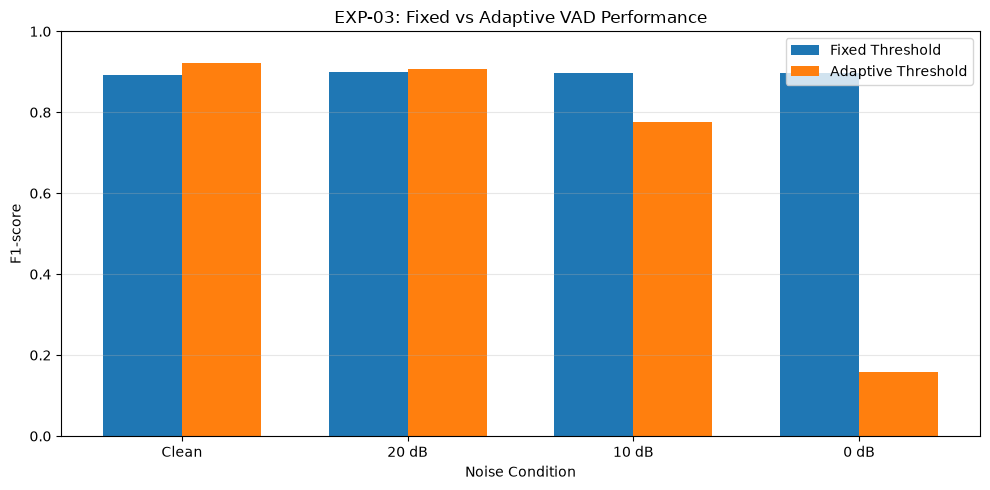

In [8]:
conditions = list(comparison_results.keys())

fixed_f1 = [
    comparison_results[name]["Fixed"]["F1"]
    for name in conditions
]

adaptive_f1 = [
    comparison_results[name]["Adaptive"]["F1"]
    for name in conditions
]

x = np.arange(len(conditions))
width = 0.35

plt.figure(figsize=(10, 5))

plt.bar(
    x - width / 2,
    fixed_f1,
    width,
    label="Fixed Threshold"
)

plt.bar(
    x + width / 2,
    adaptive_f1,
    width,
    label="Adaptive Threshold"
)

plt.xticks(x, conditions)
plt.ylim(0, 1)

plt.xlabel("Noise Condition")
plt.ylabel("F1-score")
plt.title("EXP-03: Fixed vs Adaptive VAD Performance")

plt.legend()
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

In [9]:
alpha_values = [1.0, 1.2, 1.5, 2.0, 2.5, 3.0]

alpha_results = {}

for name, rms_values in rms_results.items():

    alpha_results[name] = {}

    for alpha in alpha_values:

        threshold, noise_energy = calculate_adaptive_threshold(
            rms_values,
            rms_times,
            noise_duration=0.5,
            alpha=alpha
        )

        prediction = (rms_values > threshold).astype(int)
        aligned_prediction = prediction[indices]

        y_true = reference[valid]
        y_pred = aligned_prediction[valid]

        tn, fp, fn, tp = confusion_matrix(
            y_true,
            y_pred,
            labels=[0, 1]
        ).ravel()

        alpha_results[name][alpha] = {
            "Threshold": threshold,
            "Precision": precision_score(
                y_true, y_pred, zero_division=0
            ),
            "Recall": recall_score(
                y_true, y_pred, zero_division=0
            ),
            "F1": f1_score(
                y_true, y_pred, zero_division=0
            ),
            "FP": fp,
            "FN": fn
        }

        print(
            f"{name:6s} | "
            f"Alpha: {alpha:.1f} | "
            f"Threshold: {threshold:.4f} | "
            f"F1: {alpha_results[name][alpha]['F1']:.3f} | "
            f"FP: {fp} | FN: {fn}"
        )
        

Clean  | Alpha: 1.0 | Threshold: 0.0034 | F1: 0.902 | FP: 8 | FN: 8
Clean  | Alpha: 1.2 | Threshold: 0.0040 | F1: 0.914 | FP: 6 | FN: 8
Clean  | Alpha: 1.5 | Threshold: 0.0050 | F1: 0.904 | FP: 4 | FN: 11
Clean  | Alpha: 2.0 | Threshold: 0.0067 | F1: 0.921 | FP: 0 | FN: 12
Clean  | Alpha: 2.5 | Threshold: 0.0084 | F1: 0.907 | FP: 0 | FN: 14
Clean  | Alpha: 3.0 | Threshold: 0.0101 | F1: 0.892 | FP: 0 | FN: 16
20 dB  | Alpha: 1.0 | Threshold: 0.0046 | F1: 0.902 | FP: 8 | FN: 8
20 dB  | Alpha: 1.2 | Threshold: 0.0055 | F1: 0.906 | FP: 5 | FN: 10
20 dB  | Alpha: 1.5 | Threshold: 0.0069 | F1: 0.921 | FP: 0 | FN: 12
20 dB  | Alpha: 2.0 | Threshold: 0.0092 | F1: 0.907 | FP: 0 | FN: 14
20 dB  | Alpha: 2.5 | Threshold: 0.0114 | F1: 0.884 | FP: 0 | FN: 17
20 dB  | Alpha: 3.0 | Threshold: 0.0137 | F1: 0.812 | FP: 0 | FN: 26
10 dB  | Alpha: 1.0 | Threshold: 0.0100 | F1: 0.897 | FP: 9 | FN: 8
10 dB  | Alpha: 1.2 | Threshold: 0.0120 | F1: 0.907 | FP: 0 | FN: 14
10 dB  | Alpha: 1.5 | Threshold: 0.015

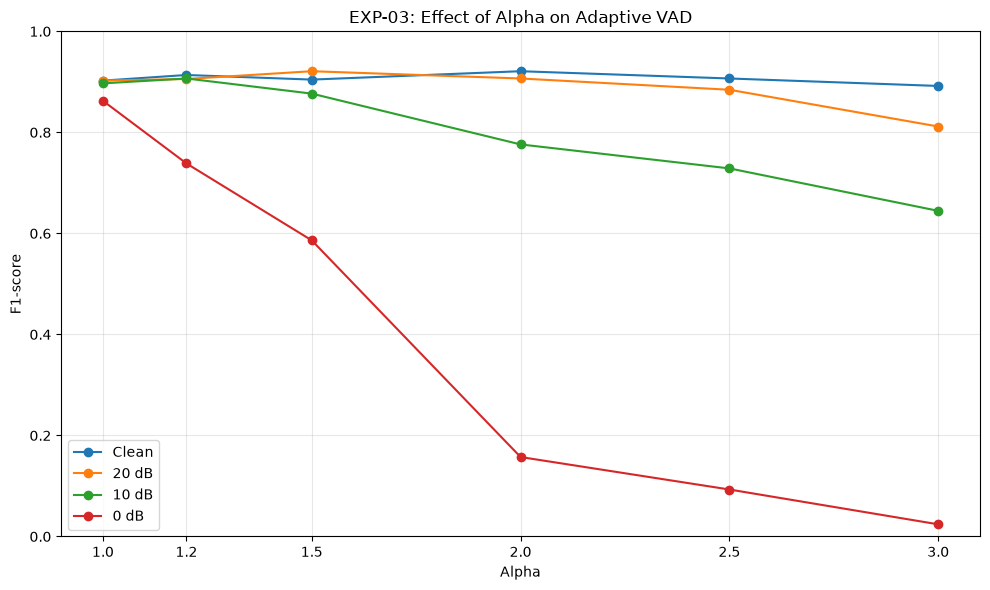

In [10]:
plt.figure(figsize=(10, 6))

for name in alpha_results:

    f1_values = [
        alpha_results[name][alpha]["F1"]
        for alpha in alpha_values
    ]

    plt.plot(
        alpha_values,
        f1_values,
        marker="o",
        label=name
    )

plt.xlabel("Alpha")
plt.ylabel("F1-score")
plt.title("EXP-03: Effect of Alpha on Adaptive VAD")

plt.ylim(0, 1)
plt.xticks(alpha_values)
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()